<a href="https://colab.research.google.com/github/merugumallarajasimha/deep_learning_basics/blob/main/ann_with_dropout_earlystop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import tensorflow as tf
from tensorflow.keras.models import  Sequential
from tensorflow.keras.layers import Dense,Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [28]:
import pandas as pd
from sklearn.datasets import load_wine

data = load_wine()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [29]:
df['target'].value_counts()

,count
target,
1,71
0,59
2,48


In [30]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [31]:
x=df.drop('target',axis=1)
y=df['target']

In [32]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [43]:
model=Sequential()
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(3,activation='softmax'))
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [44]:
non_op=model.fit(x_train,y_train,epochs=50,batch_size=32,validation_data=(x_test,y_test))

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.3380 - loss: 1.2969 - val_accuracy: 0.2778 - val_loss: 1.2433
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3521 - loss: 1.2512 - val_accuracy: 0.3333 - val_loss: 1.2030
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3803 - loss: 1.2068 - val_accuracy: 0.3333 - val_loss: 1.1651
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4085 - loss: 1.1659 - val_accuracy: 0.3611 - val_loss: 1.1266
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4296 - loss: 1.1264 - val_accuracy: 0.4167 - val_loss: 1.0899
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4437 - loss: 1.0895 - val_accuracy: 0.4722 - val_loss: 1.0543
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5000 - loss: 1.0530 - val_accuracy: 0.4722 - val_loss: 1.0198
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5493 - loss: 1.0195 - val_accuracy: 0.5000 - val_loss: 0.9869

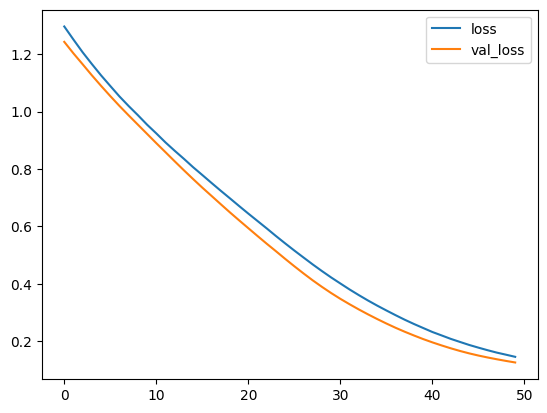

In [45]:
plt.plot(non_op.history['loss'],label='loss')
plt.plot(non_op.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

In [46]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.1258
Test Accuracy: 0.9722


In [47]:
callback = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [49]:
model1=Sequential()
model1.add(Dense(10,activation='relu'))
model1.add(Dropout(0.2))
model1.add(Dense(10,activation='relu'))
model1.add(Dropout(0.2))
model1.add(Dense(3,activation='softmax'))

In [50]:
model1.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [52]:
op=model1.fit(x_train,y_train,epochs=150,batch_size=32,validation_data=(x_test,y_test),callbacks=[callback])

Epoch 1/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8239 - loss: 0.4537 - val_accuracy: 0.9444 - val_loss: 0.3555
Epoch 2/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8169 - loss: 0.4838 - val_accuracy: 0.9444 - val_loss: 0.3439
Epoch 3/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8380 - loss: 0.4534 - val_accuracy: 0.9444 - val_loss: 0.3335
Epoch 4/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7817 - loss: 0.4828 - val_accuracy: 0.9444 - val_loss: 0.3235
Epoch 5/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8239 - loss: 0.5121 - val_accuracy: 0.9722 - val_loss: 0.3139
Epoch 6/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.8451 - loss: 0.4385 - val_accuracy: 0.9722 - val_loss: 0.3051
Epoch 7/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8451 - loss: 0.4162 - val_accuracy: 0.9722 - val_loss: 0.2956
Epoch 8/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8239 - loss: 0.4272 - val_accuracy: 0.9722 - val_loss

In [54]:
loss, accuracy = model1.evaluate(x_test, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0294
Test Accuracy: 1.0000


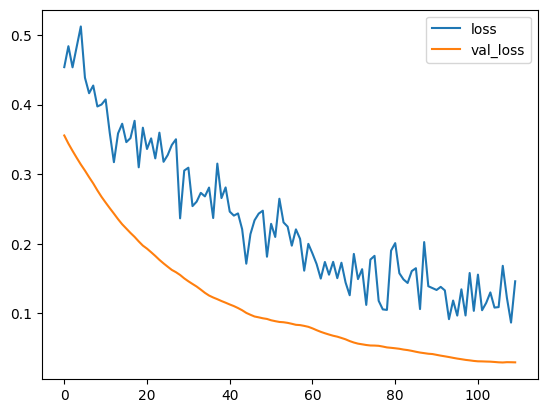

In [55]:
plt.plot(op.history['loss'],label='loss')
plt.plot(op.history['val_loss'],label='val_loss')
plt.legend()
plt.show()